In [1]:
import matplotlib.pyplot as pl
import numpy as np
import ot
from ot.gromov import gromov_wasserstein, fused_gromov_wasserstein

/home/eungyeop/anaconda3/envs/project/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n = 20 
n2 = 30 
sig = 1 
sig2 = 0.1 

np.random.seed(0)

phi = np.arange(n)[:, None]
xs = phi + sig * np.random.randn(n, 1)
ys = np.vstack(
    (np.ones((n // 2, 1)), 0 * np.ones((n // 2, 1)))
) + sig2 * np.random.randn(n, 1)

phi2 = np.arange(n2)[:, None]
xt = phi2 + sig * np.random.randn(n2, 1)
yt = np.vstack(
    (np.ones((n2 // 2, 1)), 0 * np.ones((n2 // 2, 1)))
) + sig2 * np.random.randn(n2, 1)

yt = yt[::-1, :]
p = ot.unif(n)
q = ot.unif(n2)


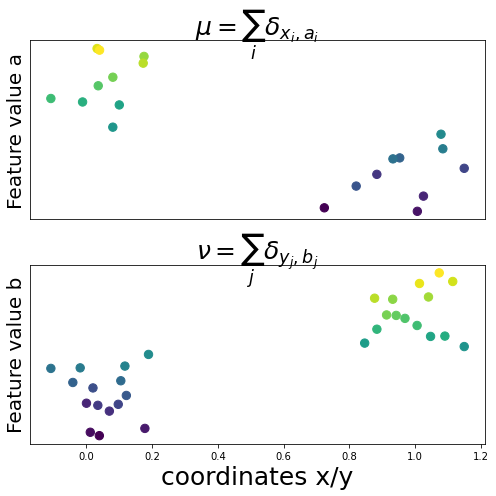

In [3]:
pl.figure(1, (7, 7))

pl.subplot(2, 1, 1)

pl.scatter(ys, xs, c=phi, s=70)
pl.ylabel("Feature value a", fontsize=20)
pl.title("$\mu=\sum_i \delta_{x_i,a_i}$", fontsize=25, y=1)
pl.xticks(())
pl.yticks(())
pl.subplot(2, 1, 2)
pl.scatter(yt, xt, c=phi2, s=70)
pl.xlabel("coordinates x/y", fontsize=25)
pl.ylabel("Feature value b", fontsize=20)
pl.title("$\\nu=\sum_j \delta_{y_j,b_j}$", fontsize=25, y=1)
pl.yticks(())
pl.tight_layout()
pl.show()

In [4]:
C1 = ot.dist(xs)
C2 = ot.dist(xt)
M = ot.dist(ys, yt)
w1 = ot.unif(C1.shape[0])
w2 = ot.unif(C2.shape[0])
Got = ot.emd([], [], M)

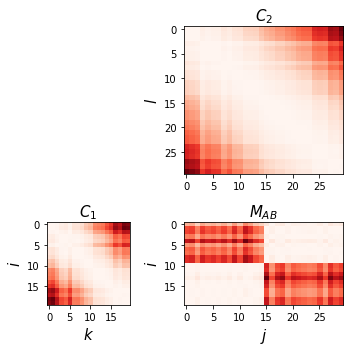

In [5]:
cmap = "Reds"

pl.figure(2, (5, 5))
fs = 15
l_x = [0, 5, 10, 15]
l_y = [0, 5, 10, 15, 20, 25]
gs = pl.GridSpec(5, 5)

ax1 = pl.subplot(gs[3:, :2])

pl.imshow(C1, cmap=cmap, interpolation="nearest")
pl.title("$C_1$", fontsize=fs)
pl.xlabel("$k$", fontsize=fs)
pl.ylabel("$i$", fontsize=fs)
pl.xticks(l_x)
pl.yticks(l_x)

ax2 = pl.subplot(gs[:3, 2:])

pl.imshow(C2, cmap=cmap, interpolation="nearest")
pl.title("$C_2$", fontsize=fs)
pl.ylabel("$l$", fontsize=fs)
pl.xticks(())
pl.yticks(l_y)
ax2.set_aspect("auto")

ax3 = pl.subplot(gs[3:, 2:], sharex=ax2, sharey=ax1)
pl.imshow(M, cmap=cmap, interpolation="nearest")
pl.yticks(l_x)
pl.xticks(l_y)
pl.ylabel("$i$", fontsize=fs)
pl.title("$M_{AB}$", fontsize=fs)
pl.xlabel("$j$", fontsize=fs)
pl.tight_layout()
ax3.set_aspect("auto")
pl.show()

In [6]:
alpha = 1e-3

ot.tic()
Gwg, logw = fused_gromov_wasserstein(
    M, C1, C2, p, q, loss_fun="square_loss", alpha=alpha, verbose=True, log=True
)
ot.toc()

# reload_ext WGW
Gg, log = gromov_wasserstein(
    C1, C2, p, q, loss_fun="square_loss", verbose=True, log=True
)

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.734412e+01|0.000000e+00|0.000000e+00
    1|2.508254e+01|8.875326e-01|2.226158e+01
    2|2.189327e+01|1.456740e-01|3.189279e+00
    3|2.189327e+01|1.622743e-16|3.552714e-15
Elapsed time : 0.003312826156616211 s
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|4.683978e+04|0.000000e+00|0.000000e+00
    1|3.860061e+04|2.134468e-01|8.239175e+03
    2|2.182948e+04|7.682787e-01|1.677113e+04
    3|2.182948e+04|0.000000e+00|0.000000e+00


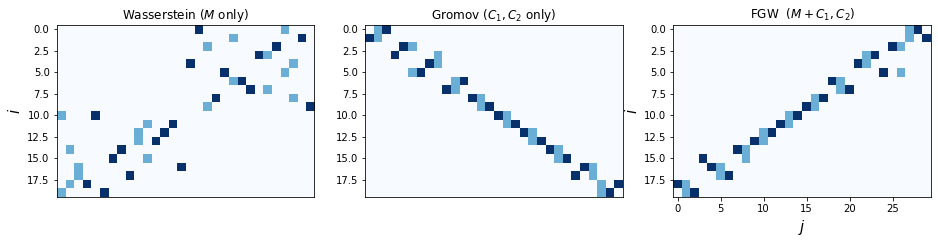

In [7]:
# visu OT matrix
cmap = "Blues"
fs = 15
pl.figure(3, (13, 5))
pl.clf()
pl.subplot(1, 3, 1)
pl.imshow(Got, cmap=cmap, interpolation="nearest")
pl.ylabel("$i$", fontsize=fs)
pl.xticks(())

pl.title("Wasserstein ($M$ only)")

pl.subplot(1, 3, 2)
pl.imshow(Gg, cmap=cmap, interpolation="nearest")
pl.title("Gromov ($C_1,C_2$ only)")
pl.xticks(())
pl.subplot(1, 3, 3)
pl.imshow(Gwg, cmap=cmap, interpolation="nearest")
pl.title("FGW  ($M+C_1,C_2$)")

pl.xlabel("$j$", fontsize=fs)
pl.ylabel("$i$", fontsize=fs)

pl.tight_layout()
pl.show()

### Pytorch FGW

In [8]:
import torch 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
import matplotlib.collections as mc

In [9]:
import torch
import matplotlib.pyplot as plt
import matplotlib.collections as mc
import numpy as np
import seaborn as sns

class FGWSolver:
    """
    PyTorch implementation of Entropic Fused Gromov-Wasserstein.
    (Solving logic remains same as previous verified version)
    """
    @staticmethod
    def sinkhorn(C, a, b, epsilon=1e-2, num_iter=100):
        K = torch.exp(-C / epsilon)
        u = torch.ones_like(a)
        v = torch.ones_like(b)
        
        for _ in range(num_iter):
            Kv = torch.matmul(K, v.unsqueeze(-1)).squeeze(-1)
            u = a / (Kv + 1e-8)
            KTu = torch.matmul(K.transpose(-1, -2), u.unsqueeze(-1)).squeeze(-1)
            v = b / (KTu + 1e-8)
            
        Pi = u.unsqueeze(-1) * K * v.unsqueeze(-2)
        return Pi

    @staticmethod
    def gw_cost(C1, C2, Pi):
        mu = Pi.sum(dim=-1, keepdim=True)
        nu = Pi.sum(dim=-2, keepdim=True)
        
        term1 = torch.matmul(C1**2, mu)
        term2 = torch.matmul(C2**2, nu.transpose(-1, -2)).transpose(-1, -2)
        term3 = -2 * torch.matmul(torch.matmul(C1, Pi), C2.transpose(-1, -2))
        
        return term1 + term2 + term3

    @staticmethod
    def fgw(M, C1, C2, a, b, alpha=0.5, epsilon=0.05, num_iter=50):
        Pi = torch.matmul(a.unsqueeze(-1), b.unsqueeze(-2))
        C_total = None
        
        for i in range(num_iter):
            C_gw = FGWSolver.gw_cost(C1, C2, Pi)
            C_total = (1 - alpha) * M + alpha * C_gw
            Pi = FGWSolver.sinkhorn(C_total, a, b, epsilon=epsilon, num_iter=100)
            
        return Pi, C_total


        
class FGWVisualizer:
    @staticmethod
    def plot_matrices(C1, C2, M, title_prefix=""):
        """C1, C2, M 행렬 시각화 (1x3)"""
        C1 = C1.squeeze().cpu().numpy()
        C2 = C2.squeeze().cpu().numpy()
        M = M.squeeze().cpu().numpy()
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        sns.heatmap(C1, ax=axes[0], cmap='Reds', square=True, cbar=True)
        axes[0].set_title(f"{title_prefix} C1 (Source Structure)")
        
        sns.heatmap(C2, ax=axes[1], cmap='Reds', square=True, cbar=True)
        axes[1].set_title(f"{title_prefix} C2 (Target Structure)")
        
        sns.heatmap(M, ax=axes[2], cmap='Reds', square=True, cbar=True)
        axes[2].set_title(f"{title_prefix} M (Feature Cost)")
        
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_plans(Pi_W, Pi_GW, Pi_FGW):
        """Transport Plans 시각화 (1x3) - Wasserstein, Gromov, FGW 비교"""
        plans = [
            (Pi_W, "Wasserstein (Feature Only)"),
            (Pi_GW, "Gromov (Structure Only)"),
            (Pi_FGW, "Fused GW (Balanced)")
        ]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        for i, (pi, title) in enumerate(plans):
            pi_np = pi.squeeze().detach().cpu().numpy()
            sns.heatmap(pi_np, ax=axes[i], cmap='Blues', square=True, cbar=True)
            axes[i].set_title(title, fontsize=12, fontweight='bold')
            axes[i].set_xlabel("Target Nodes (K)")
            axes[i].set_ylabel("Source Nodes (N)")
            
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_graph_matching(xs, ys, xt, yt, Pi, title="Graph Matching"):
        """
        Source(원)와 Target(다이아몬드) 그래프 매칭 시각화 (인덱스 포함)
        """
        xs = xs.squeeze().cpu().numpy()
        ys = ys.squeeze().cpu().numpy()
        xt = xt.squeeze().cpu().numpy()
        yt = yt.squeeze().cpu().numpy()
        pi = Pi.squeeze().detach().cpu().numpy()

        x_shift = xs.max() - xt.min() + 3.0 
        xt_shifted = xt + x_shift

        plt.figure(figsize=(14, 7))
        ax = plt.gca()

        # 1. 연결선 그리기
        threshold = 1e-3 
        indices = np.argwhere(pi > threshold)
        
        lines = []
        colors = []
        linewidths = []

        for i, j in indices:
            p1 = (xs[i], ys[i])
            p2 = (xt_shifted[j], yt[j])
            lines.append([p1, p2])
            
            strength = pi[i, j] / pi.max()
            colors.append((0.2, 0.2, 0.2, strength * 0.8))
            linewidths.append(strength * 2.5)

        lc = mc.LineCollection(lines, colors=colors, linewidths=linewidths, zorder=1)
        ax.add_collection(lc)

        # 2. 노드 그리기 (Feature Value로 색칠)
        sc1 = plt.scatter(xs, ys, c=ys, cmap='coolwarm', s=150, edgecolors='k', linewidth=1.5,
                          marker='o', zorder=2, label='Source')
        sc2 = plt.scatter(xt_shifted, yt, c=yt, cmap='coolwarm', s=150, edgecolors='k', linewidth=1.5,
                          marker='D', zorder=2, label='Target')

        # ❗️ [추가] 각 노드에 인덱스 텍스트 추가
        text_offset_x = 0.5 # 노드 중심에서 텍스트가 떨어질 거리
        text_offset_y = 0.05 # 노드 중심에서 텍스트가 떨어질 거리 (y축)

        for i in range(len(xs)):
            ax.text(xs[i] + text_offset_x, ys[i] + text_offset_y, str(i), 
                    fontsize=8, ha='left', va='center', color='black', zorder=3)
        for i in range(len(xt_shifted)):
            ax.text(xt_shifted[i] + text_offset_x, yt[i] + text_offset_y, str(i), 
                    fontsize=8, ha='left', va='center', color='black', zorder=3)

        # 3. 텍스트 및 장식
        plt.title(title, fontsize=18, pad=20)
        
        plt.axis('off')

        plt.text(xs.mean(), ys.max() + 0.5, "Source Graph\n(Structure Only)", 
                 ha='center', va='bottom', fontsize=14, fontweight='bold')
        plt.text(xt_shifted.mean(), yt.max() + 0.5, "Target Graph\n(Structure Only)", 
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

        cbar = plt.colorbar(sc1, label="Feature Value (Color)", pad=0.01, shrink=0.8)
        
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Source Node',
                   markerfacecolor='lightgray', markeredgecolor='k', markersize=10),
            Line2D([0], [0], marker='D', color='w', label='Target Node',
                   markerfacecolor='lightgray', markeredgecolor='k', markersize=10)
        ]
        plt.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
                   ncol=2, frameon=False, fontsize=12)

        plt.tight_layout()
        plt.show()

In [10]:
# --- 1. Generate Toy Data ---
torch.manual_seed(42)
n = 20
n2 = 10 # 매칭 보기 편하게 개수 동일하게 설정 (다르게 해도 됨)
sig = 1

# Structure (X coordinate)
phi = torch.arange(n, dtype=torch.float32).unsqueeze(1)
xs = phi + sig * torch.randn(n, 1)

phi2 = torch.arange(n2, dtype=torch.float32).unsqueeze(1)
xt = phi2 + sig * torch.randn(n2, 1)

# Features (Y value) - Reverse Pattern
# Source: High -> Low (Top to Bottom)
# Target: Low -> High (Bottom to Top)
ys = torch.linspace(1, 0, n).unsqueeze(1) + 0.1 * torch.randn(n, 1)
yt = torch.linspace(0, 1, n2).unsqueeze(1) + 0.1 * torch.randn(n2, 1)

# --- 2. Compute Matrices ---
# Structure Cost (Coordinate distance)
C1 = torch.cdist(xs, xs, p=2)**2; C1 /= C1.max()
C2 = torch.cdist(xt, xt, p=2)**2; C2 /= C2.max()

# Feature Cost (Value distance)
M = torch.cdist(ys, yt, p=2)**2; M /= M.max()

a = torch.ones(n) / n
b = torch.ones(n2) / n2

M_b, C1_b, C2_b = M.unsqueeze(0), C1.unsqueeze(0), C2.unsqueeze(0)
a_b, b_b = a.unsqueeze(0), b.unsqueeze(0)


>>> 1. Running Wasserstein Only (alpha=0) Feature : 1.0, Structure : 0.0 ...
>>> 2. Running Fused GW (alpha=0.3) Feature : 0.7, Structure : 0.3 ...
>>> 3. Running Fused GW (alpha=0.5) Feature : 0.5, Structure : 0.5 ...
>>> 4. Running Fused GW (alpha=0.8) Feature : 0.8, Structure : 0.2 ...
>>> 5. Running Gromov Only (alpha=1) Feature : 0.0, Structure : 1.0 ...

--- [1] Transport Plans (Heatmaps) ---
>>> Comparison: Alpha = 0.0


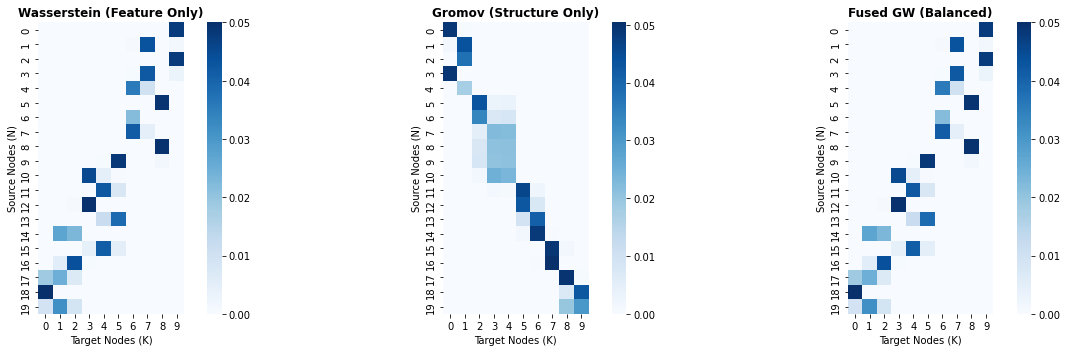

>>> Comparison: Alpha = 0.3


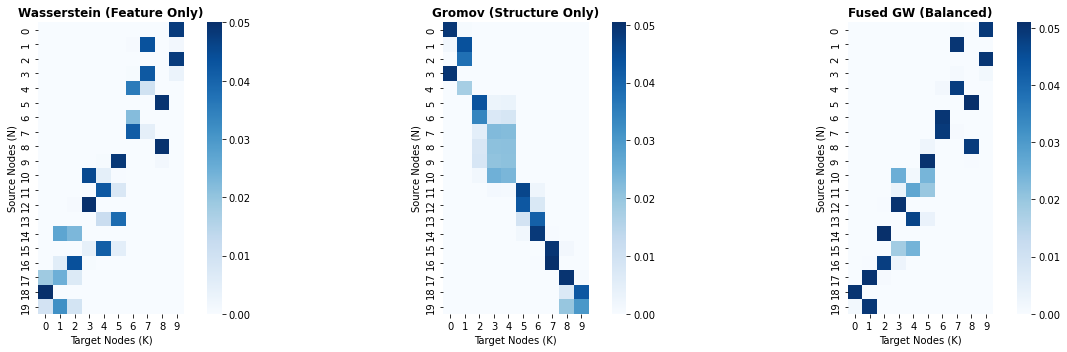

>>> Comparison: Alpha = 0.5


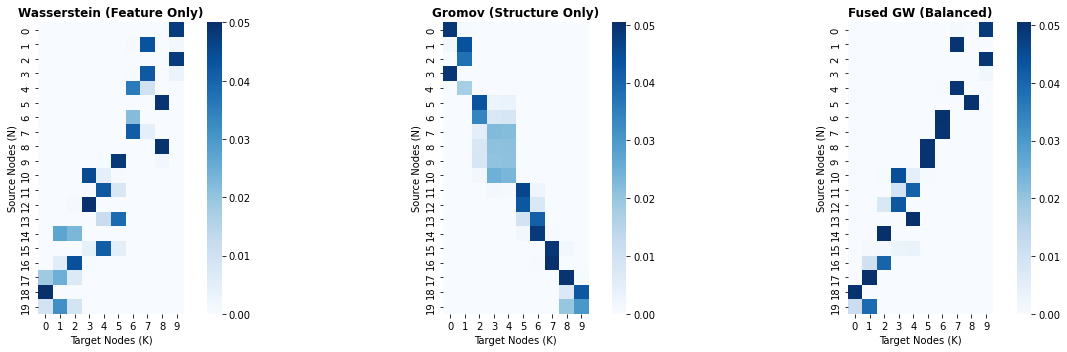

>>> Comparison: Alpha = 0.8


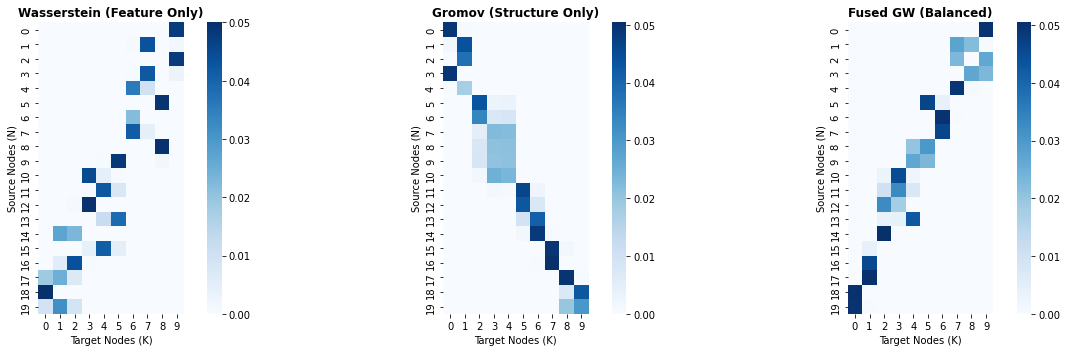

>>> Comparison: Alpha = 1.0


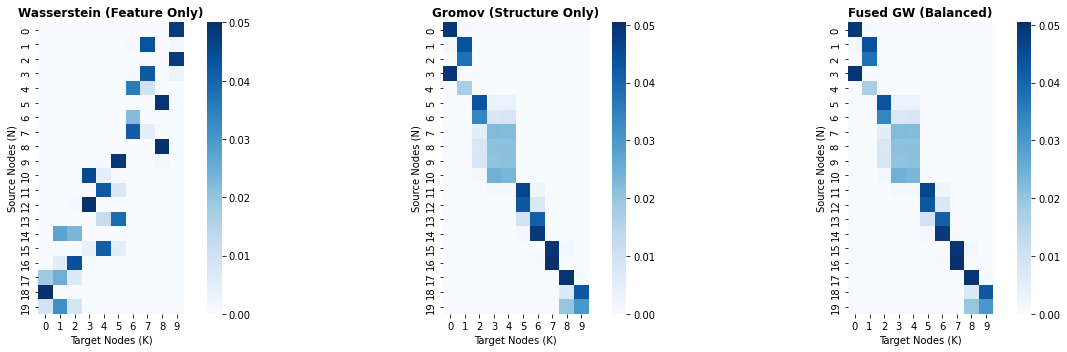


--- [2] Graph Matching (Connections) ---


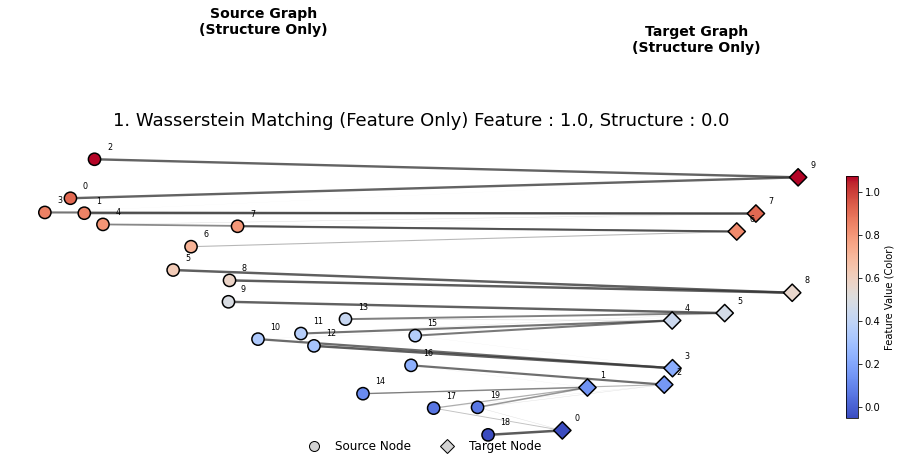

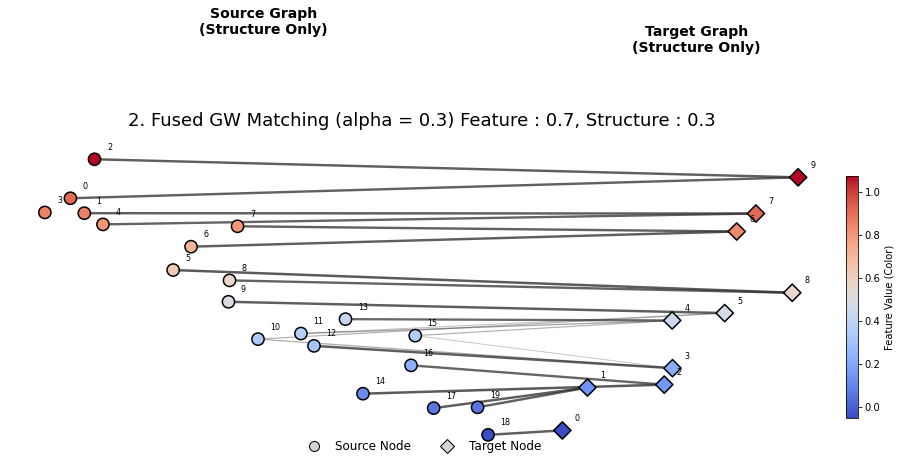

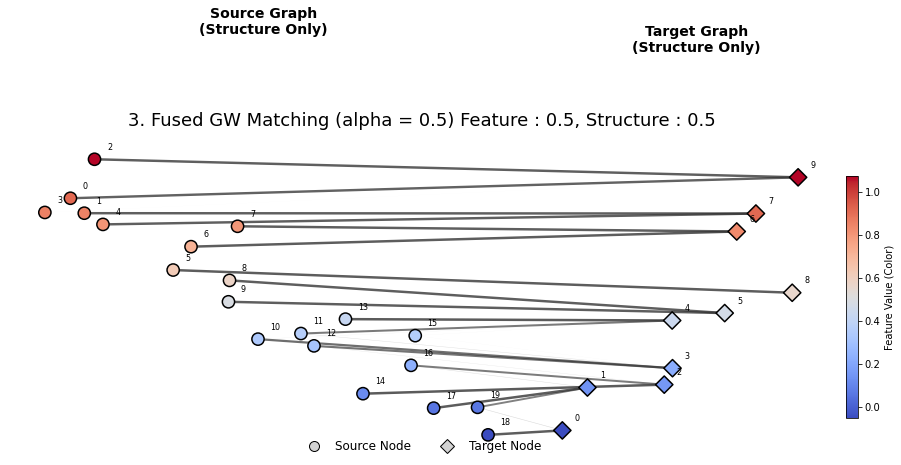

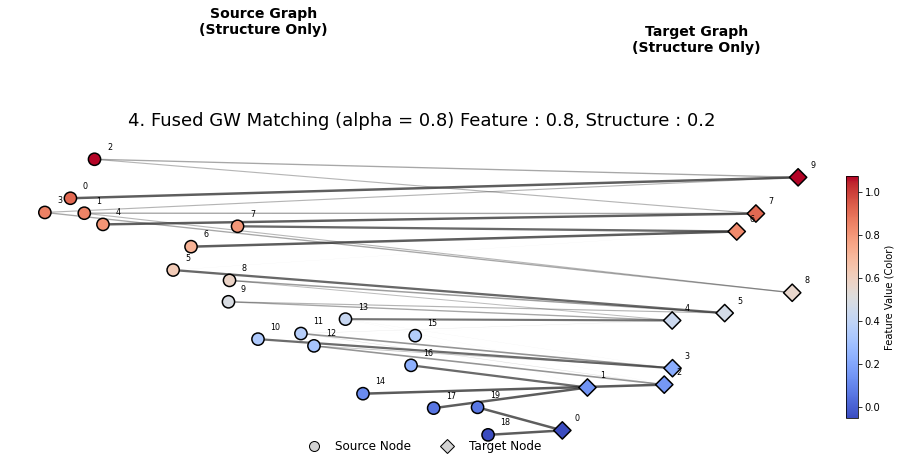

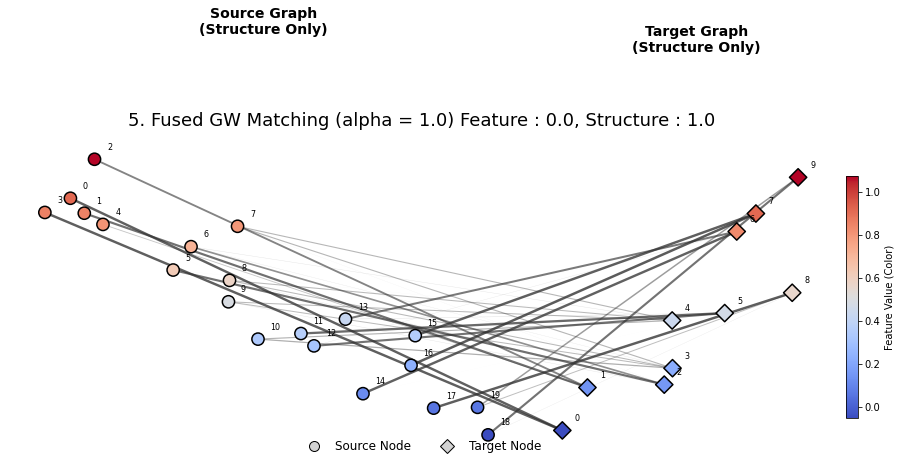

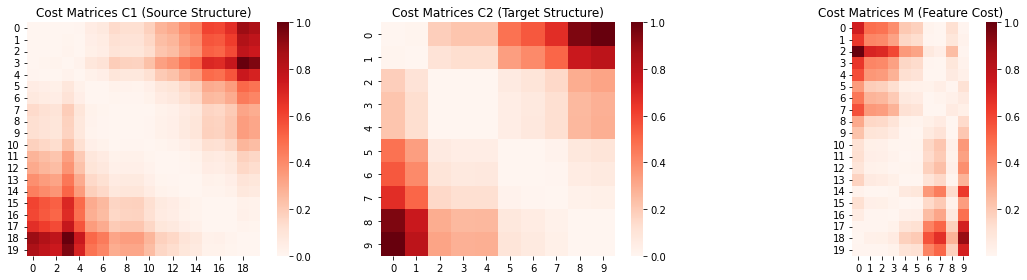

In [12]:
# --- 3. Run Solvers ---
epsilon_ = 0.001
# # 1. Wasserstein (alpha=0)
# print(">>> 1. Running Wasserstein Only (alpha=0)...")
Pi_W, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.0, epsilon=epsilon_)


Pi_GW, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=1.0, epsilon=epsilon_)
# 2. FGW Variatons
print(">>> 1. Running Wasserstein Only (alpha=0) Feature : 1.0, Structure : 0.0 ...")
Pi_FGW_00, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.0, epsilon=epsilon_)

print(">>> 2. Running Fused GW (alpha=0.3) Feature : 0.7, Structure : 0.3 ...")
Pi_FGW_03, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.3, epsilon=epsilon_)

print(">>> 3. Running Fused GW (alpha=0.5) Feature : 0.5, Structure : 0.5 ...")
Pi_FGW_05, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.5, epsilon=epsilon_)

print(">>> 4. Running Fused GW (alpha=0.8) Feature : 0.8, Structure : 0.2 ...")
Pi_FGW_08, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=0.8, epsilon=epsilon_)

# 3. Gromov (alpha=1) -> ❗️ 먼저 계산해야 함 (Pi_GW 정의)
print(">>> 5. Running Gromov Only (alpha=1) Feature : 0.0, Structure : 1.0 ...")
Pi_FGW_10, _ = FGWSolver.fgw(M_b, C1_b, C2_b, a_b, b_b, alpha=1.0, epsilon=epsilon_)

# --- 4. Visualize ---

print("\n--- [1] Transport Plans (Heatmaps) ---")

print(">>> Comparison: Alpha = 0.0")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_00)

print(">>> Comparison: Alpha = 0.3")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_03)

print(">>> Comparison: Alpha = 0.5")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_05)

print(">>> Comparison: Alpha = 0.8")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_08)

print(">>> Comparison: Alpha = 1.0")
FGWVisualizer.plot_plans(Pi_W, Pi_GW, Pi_FGW_10)

print("\n--- [2] Graph Matching (Connections) ---")

# (1) Wasserstein Matching
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_00, title="1. Wasserstein Matching (Feature Only) Feature : 1.0, Structure : 0.0")

# (2) FGW Matching (0.3)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_03, title="2. Fused GW Matching (alpha = 0.3) Feature : 0.7, Structure : 0.3")

# (3) FGW Matching (0.5)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_05, title="3. Fused GW Matching (alpha = 0.5) Feature : 0.5, Structure : 0.5")

# (4) FGW Matching (0.8)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_08, title="4. Fused GW Matching (alpha = 0.8) Feature : 0.8, Structure : 0.2")

# (5) FGW Matching (0.8)
FGWVisualizer.plot_graph_matching(xs, ys, xt, yt, Pi_FGW_10, title="5. Fused GW Matching (alpha = 1.0) Feature : 0.0, Structure : 1.0")

# Cost Matrices
FGWVisualizer.plot_matrices(C1, C2, M, title_prefix="Cost Matrices")